# SQLStorm — TPC-H vs StackOverflow: query corpus and run outcomes

SQLStorm ships LLM-generated analytic queries for several schemas. Two of them are on the server:

| dataset | queries | database | run log |
|---|---|---|---|
| **TPC-H** | `queries/tpch/SQLStorm/` (all 17,036) | `tpch_idx` (SF 1, indexed) | `logs/sqlstorm/` |
| **StackOverflow** | `queries/stackoverflow/SQLStorm/` (the 11,794 upstream marks valid for PostgreSQL) | `stackoverflow_1gb` (dba.stackexchange) | `logs/sqlstorm_stackoverflow/` |

Both runs use the same command: one cache-priming warm-up and one measured single copy per query,
clock pinned at 2.5 GHz, thermal gate 40–60 °C, **15 s statement timeout**, PostgreSQL 18.4.
For each dataset we parse the SQL text into a feature table, report construct / table / function
frequency, split the run outcomes into pass / timeout / error, and then **compare the two**.

Deliverables (`csv/`): per dataset a feature table, all failed queries (tagged timeout/error) and
the timeouts only — `sqlstorm_*.csv` for TPC-H (unchanged names) and `sqlstorm_stackoverflow_*.csv`.
One claim per figure; units on every axis.

## 0. Pull queries and run logs → `cache/sqlstorm_cache/`

Query files are streamed as one tarball over SSH and cached (TPC-H in `cache/sqlstorm_cache/queries/`,
StackOverflow in `cache/sqlstorm_cache/stackoverflow/queries/`; both git-ignored). Query files are
only re-pulled when the cache is incomplete or `REFRESH = True`; the run logs are re-pulled every
time (the StackOverflow run may still be in progress). Everything falls back to the cache if the
server is unreachable.

In [1]:
# %pip install paramiko pandas matplotlib
import io, re, tarfile, time
from pathlib import Path
import numpy as np
import pandas as pd

SSH_HOST = "192.168.1.42"
SSH_USER = "user01"
SSH_PASS = "a"                                   # demo credential
REMOTE_ROOT = "/home/user01/GreenSQL"
CACHE = Path("cache/sqlstorm_cache")
REFRESH = False                                  # True forces a re-pull of the query files

DATASETS = {
    "tpch": dict(label="TPC-H", db="tpch_idx", expect=17036,
                 qdir=f"{REMOTE_ROOT}/queries/tpch/SQLStorm",
                 logdir=f"{REMOTE_ROOT}/logs/sqlstorm",
                 qcache=CACHE / "queries", lcache=CACHE / "logs",
                 csv_prefix="csv/sqlstorm_", extra={}),
    "stackoverflow": dict(label="StackOverflow", db="stackoverflow_1gb", expect=11794,
                          qdir=f"{REMOTE_ROOT}/queries/stackoverflow/SQLStorm",
                          logdir=f"{REMOTE_ROOT}/logs/sqlstorm_stackoverflow",
                          qcache=CACHE / "stackoverflow" / "queries",
                          lcache=CACHE / "stackoverflow" / "logs",
                          csv_prefix="csv/sqlstorm_stackoverflow_",
                          extra={"SQLStorm.selection.csv":
                                 f"{REMOTE_ROOT}/queries/stackoverflow/SQLStorm.selection.csv"}),
}
KEYS = list(DATASETS)
DCOL = {"tpch": "#2a78d6", "stackoverflow": "#e8710a"}
LBL = {k: d["label"] for k, d in DATASETS.items()}


def log_files(d):
    return [f"query_{kind}_{d['db']}.csv" for kind in ("timing", "samples", "catalog")]


def _ssh():
    import paramiko
    cl = paramiko.SSHClient()
    cl.set_missing_host_key_policy(paramiko.AutoAddPolicy())
    cl.connect(SSH_HOST, username=SSH_USER, password=SSH_PASS,
               timeout=45, banner_timeout=45, auth_timeout=45)
    return cl


def pull_queries(key):
    d = DATASETS[key]; qc = d["qcache"]; qc.mkdir(parents=True, exist_ok=True)
    have = len(list(qc.glob("*.sql")))
    if have >= d["expect"] and not REFRESH:
        return f"cache ({have} files)"
    try:
        cl = _ssh()
        try:
            _, out, err = cl.exec_command(f"tar -C {d['qdir']} -cf - .")
            data = out.read()
            if not data:
                raise RuntimeError(f"empty tar stream ({err.read().decode()[:120]})")
            n = 0
            with tarfile.open(fileobj=io.BytesIO(data)) as tf:
                for m in tf.getmembers():
                    if m.isfile() and m.name.endswith(".sql"):
                        (qc / Path(m.name).name).write_bytes(tf.extractfile(m).read())
                        n += 1
            return f"server ({n} files, {len(data) / 1e6:.0f} MB tar)"
        finally:
            cl.close()
    except Exception as exc:
        have = len(list(qc.glob("*.sql")))
        if have == 0:
            raise RuntimeError(f"{exc}\nNo query cache at '{qc}/'.") from exc
        return f"cache ({have} files; pull failed: {type(exc).__name__})"


def pull_logs(key):
    d = DATASETS[key]; lc = d["lcache"]; lc.mkdir(parents=True, exist_ok=True)
    wanted = {fn: f"{d['logdir']}/{fn}" for fn in log_files(d)} | d["extra"]
    try:
        cl = _ssh()
        try:
            with cl.open_sftp() as sftp:
                for fn, rp in wanted.items():
                    with sftp.open(rp) as f:
                        f.prefetch()
                        (lc / fn).write_bytes(f.read())
            return "server"
        finally:
            cl.close()
    except Exception as exc:
        if not all((lc / fn).exists() for fn in wanted):
            raise RuntimeError(f"{exc}\nLog cache '{lc}/' incomplete.") from exc
        age_h = (time.time() - min((lc / fn).stat().st_mtime for fn in wanted)) / 3600
        return f"cache ({age_h:.1f} h old; pull failed: {type(exc).__name__})"


for k in KEYS:
    print(f"{LBL[k]:14}  queries: {pull_queries(k)};  logs: {pull_logs(k)}")

TPC-H           queries: cache (17036 files);  logs: server
StackOverflow   queries: cache (11794 files);  logs: server


## 1. Parse every query into a feature table

The `--` header and the harness's `EXPLAIN (ANALYZE …)` wrapper are stripped so we measure the
query itself. Per query: clause presence, join count and kinds, tables referenced, common
functions, and size. **Tables come from each database's catalog** (the base relations), and a
table counts as referenced only right after `FROM`, `JOIN` or a comma — StackOverflow has columns
named like tables (e.g. `Posts.Tags`), which a bare word match would miscount.

In [2]:
AGGS   = ["count", "sum", "avg", "min", "max", "string_agg", "array_agg"]
STRFUN = ["substring", "concat", "replace", "upper", "lower", "trim", "coalesce",
          "cast", "round", "extract", "date_trunc", "case"]
EXPLAIN_RE = re.compile(r"^\s*EXPLAIN\s*\([^)]*\)\s*", re.I)
LINE_COMMENT = re.compile(r"--[^\n]*")
BLOCK_COMMENT = re.compile(r"/\*.*?\*/", re.S)


def clean_sql(txt):
    return EXPLAIN_RE.sub("", BLOCK_COMMENT.sub(" ", LINE_COMMENT.sub(" ", txt)))


def wc(pat, U):
    return len(re.findall(pat, U))


def catalog(key):
    d = DATASETS[key]
    c = pd.read_csv(d["lcache"] / f"query_catalog_{d['db']}.csv")
    return c[c["relkind"] == "r"].drop_duplicates("relname").set_index("relname")


def features(txt, tables):
    t = clean_sql(txt)
    U = t.upper()
    n_select = wc(r"\bSELECT\b", U)
    f = dict(
        chars=len(t.strip()), lines=txt.count("\n") + 1, tokens=wc(r"\w+", t),
        n_select=n_select, n_join=wc(r"\bJOIN\b", U), n_where=wc(r"\bWHERE\b", U),
        is_cte=bool(re.match(r"\s*WITH\b", U)),
        has_where=bool(re.search(r"\bWHERE\b", U)), has_join=bool(re.search(r"\bJOIN\b", U)),
        has_group=bool(re.search(r"\bGROUP\s+BY\b", U)), has_having=bool(re.search(r"\bHAVING\b", U)),
        has_order=bool(re.search(r"\bORDER\s+BY\b", U)), has_limit=bool(re.search(r"\bLIMIT\b", U)),
        has_distinct=bool(re.search(r"\bDISTINCT\b", U)), has_case=bool(re.search(r"\bCASE\b", U)),
        has_window=bool(re.search(r"\bOVER\s*\(", U)),
        has_union=bool(re.search(r"\bUNION\b|\bINTERSECT\b|\bEXCEPT\b", U)),
        has_exists=bool(re.search(r"\bEXISTS\b", U)),
        has_in_subq=bool(re.search(r"\bIN\s*\(\s*SELECT\b", U)),
        has_like=bool(re.search(r"\bLIKE\b|\bILIKE\b", U)),
        has_recursive=bool(re.search(r"\bWITH\s+RECURSIVE\b", U)),
        has_subquery=n_select > 1,
    )
    for jt in ["inner", "left", "right", "full", "cross"]:
        f[f"join_{jt}"] = bool(re.search(rf"\b{jt.upper()}\s+(OUTER\s+)?JOIN\b", U))
    refs = {tb for tb in tables
            if re.search(rf"(?:\bFROM|\bJOIN|,)\s*(?:PUBLIC\.)?\"?{tb.upper()}\"?\b", U)}
    f["n_tables"] = len(refs)
    for tb in tables:
        f[f"tbl_{tb}"] = tb in refs
    for fn in AGGS + STRFUN:
        f[f"fn_{fn}"] = bool(re.search(rf"\b{fn.upper()}\s*\(", U))
    return f


CAT, TABLES, FEAT = {}, {}, {}
for k in KEYS:
    d = DATASETS[k]
    CAT[k] = catalog(k)
    TABLES[k] = list(CAT[k].index)
    rows = []
    for p in sorted(d["qcache"].glob("*.sql")):
        fe = features(p.read_text(encoding="utf-8", errors="replace"), TABLES[k])
        fe["qid"] = p.stem
        rows.append(fe)
    FEAT[k] = pd.DataFrame(rows).set_index("qid")
    FEAT[k].to_csv(f"{d['csv_prefix']}query_features.csv")
    print(f"{LBL[k]:14} {len(FEAT[k]):6} queries x {FEAT[k].shape[1]} features, "
          f"{len(TABLES[k])} tables -> {d['csv_prefix']}query_features.csv")

TPC-H           17036 queries x 55 features, 8 tables -> csv/sqlstorm_query_features.csv
StackOverflow   11794 queries x 60 features, 13 tables -> csv/sqlstorm_stackoverflow_query_features.csv


### 1a. The two corpora and databases at a glance

In [3]:
rows = []
for k in KEYS:
    c = CAT[k]; F = FEAT[k]
    big = c["reltuples"].idxmax()
    rows.append({"dataset": LBL[k], "query files": len(F), "database": DATASETS[k]["db"],
                 "tables": len(c), "DB size (MB)": round(c["total_bytes"].sum() / 1e6),
                 "largest table": f"{big} ({c.loc[big, 'reltuples'] / 1e6:.2f} M rows)",
                 "median tokens": int(F["tokens"].median()),
                 "median joins": int(F["n_join"].median()),
                 "median tables": int(F["n_tables"].median())})
OVERVIEW = pd.DataFrame(rows).set_index("dataset")
print(OVERVIEW.T.to_string())

sel = pd.read_csv(DATASETS["stackoverflow"]["lcache"] / "SQLStorm.selection.csv")
SEL = sel["status"].value_counts()
print(f"\nStackOverflow upstream selection ({len(sel)} queries): " +
      ", ".join(f"{s} {n}" for s, n in SEL.items()) +
      " — only 'included' are run. TPC-H is the full, unfiltered set.")

dataset                         TPC-H        StackOverflow
query files                     17036                11794
database                     tpch_idx    stackoverflow_1gb
tables                              8                   13
DB size (MB)                     2188                 1225
largest table  lineitem (6.00 M rows)  votes (0.93 M rows)
median tokens                     132                  151
median joins                        5                    3
median tables                       5                    4

StackOverflow upstream selection (18251 queries): included 11794, excluded_invalid 5664, excluded_postgres_disagrees 793 — only 'included' are run. TPC-H is the full, unfiltered set.


## 2. SQL construct frequency — TPC-H vs StackOverflow

Share of each corpus containing each construct. The generator is the same, the schemas differ:
this shows whether the StackOverflow queries lean on different SQL.

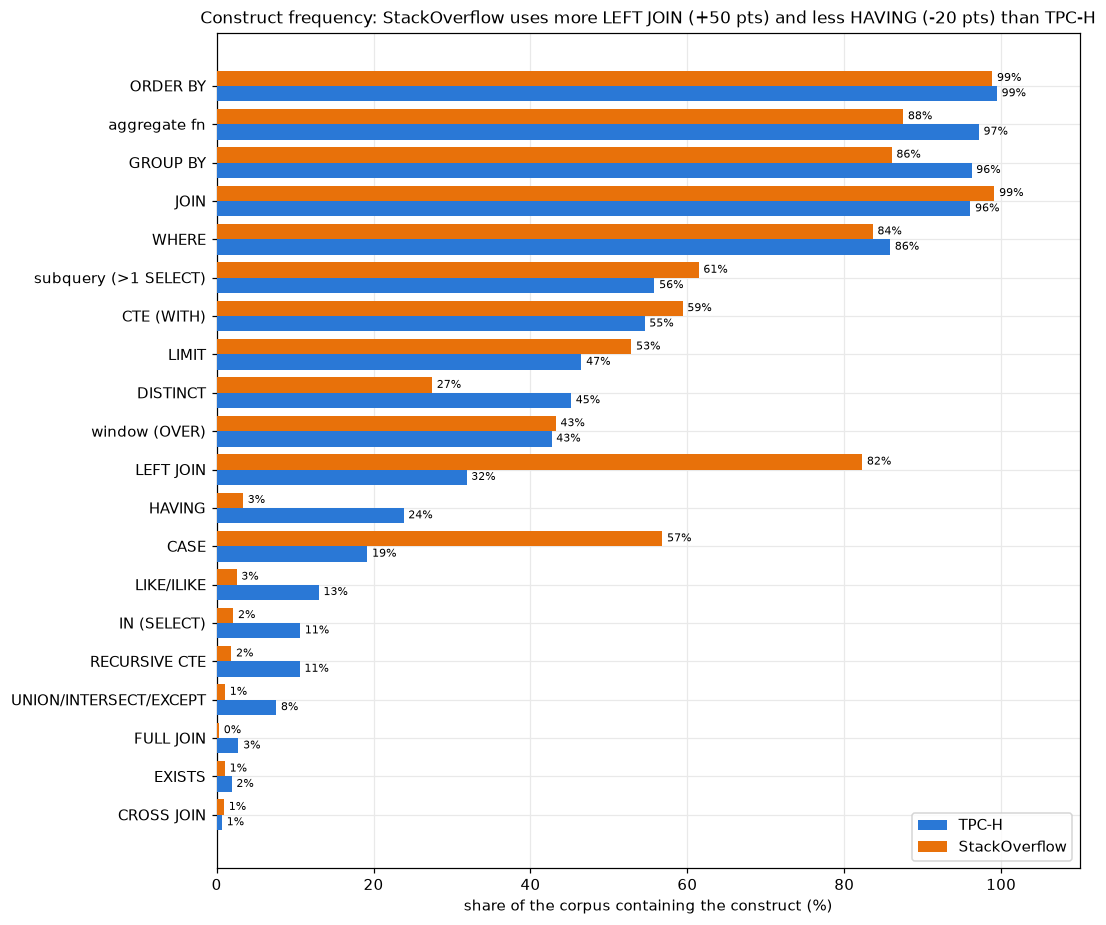

In [4]:
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white",
                     "savefig.facecolor": "white", "axes.grid": True,
                     "grid.color": "#e9e9e9", "axes.axisbelow": True,
                     "font.size": 9.5, "figure.dpi": 110})
FIG = Path("figures"); FIG.mkdir(exist_ok=True)


def savefig(fig, name):
    fig.savefig(FIG / f"{name}.svg", bbox_inches="tight")


CONSTRUCTS = [("JOIN", "has_join"), ("WHERE", "has_where"), ("GROUP BY", "has_group"),
              ("ORDER BY", "has_order"), ("aggregate fn", None),
              ("subquery (>1 SELECT)", "has_subquery"), ("DISTINCT", "has_distinct"),
              ("CTE (WITH)", "is_cte"), ("RECURSIVE CTE", "has_recursive"), ("CASE", "has_case"),
              ("HAVING", "has_having"), ("LIMIT", "has_limit"), ("window (OVER)", "has_window"),
              ("LIKE/ILIKE", "has_like"), ("UNION/INTERSECT/EXCEPT", "has_union"),
              ("EXISTS", "has_exists"), ("IN (SELECT)", "has_in_subq"),
              ("LEFT JOIN", "join_left"), ("FULL JOIN", "join_full"), ("CROSS JOIN", "join_cross")]


def share(F, col):
    return 100 * (F[[f"fn_{a}" for a in AGGS]].any(axis=1).mean() if col is None else F[col].mean())


CF = pd.DataFrame({k: {lbl: share(FEAT[k], col) for lbl, col in CONSTRUCTS} for k in KEYS})
CF = CF.sort_values("tpch")


def grouped_barh(ax, M, fmt="{:.0f}%"):
    y = np.arange(len(M)); h = 0.4
    for i, k in enumerate(KEYS):
        ax.barh(y + (i - 0.5) * h, M[k], h, color=DCOL[k], label=LBL[k], zorder=3)
        for yy, v in zip(y + (i - 0.5) * h, M[k]):
            ax.text(v + 0.6, yy, fmt.format(v), va="center", fontsize=7)
    ax.set_yticks(y); ax.set_yticklabels(M.index)


fig, ax = plt.subplots(figsize=(10, 8.5))
grouped_barh(ax, CF)
ax.set_xlabel("share of the corpus containing the construct (%)")
ax.set_xlim(0, 110); ax.legend(loc="lower right")
d = (CF["stackoverflow"] - CF["tpch"])
up, dn = d.idxmax(), d.idxmin()
ax.set_title(f"Construct frequency: StackOverflow uses more {up} ({d[up]:+.0f} pts) and less "
             f"{dn} ({d[dn]:+.0f} pts) than TPC-H", fontsize=11)
fig.tight_layout(); savefig(fig, "sqlstorm_construct_freq"); plt.show()

## 3. Structural complexity

Joins, distinct tables referenced and size in tokens, as a share of each corpus so the two sizes
compare directly.

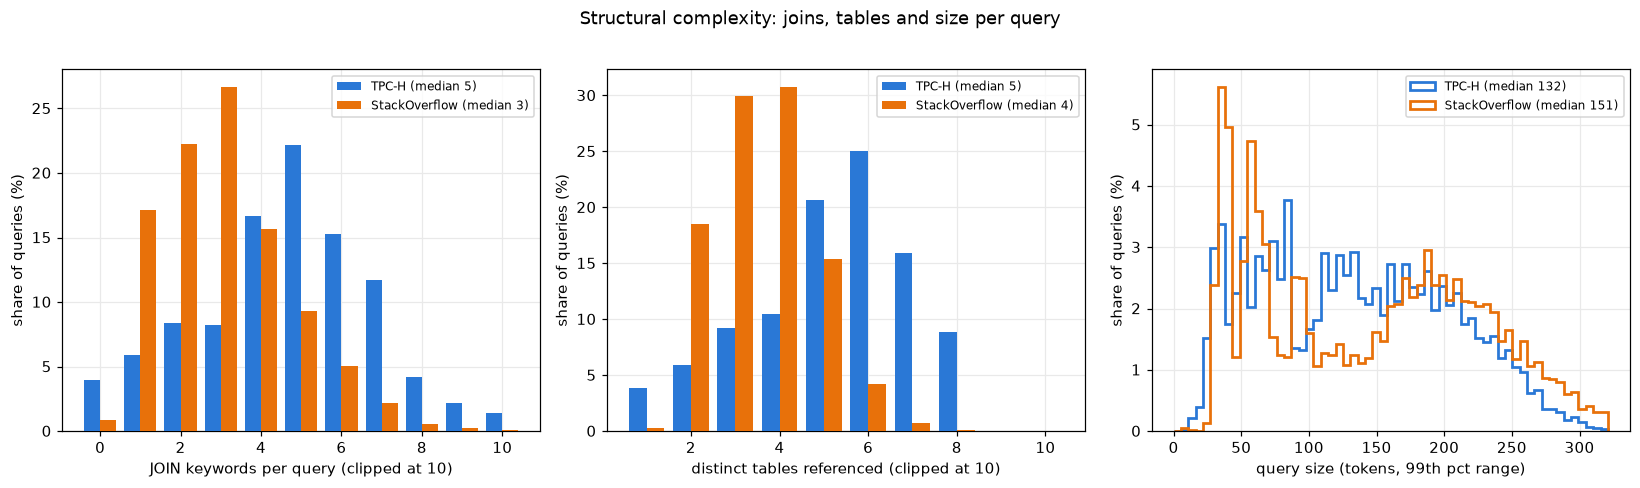

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
w = 0.4
for ax, col, clip, xl in [(axes[0], "n_join", 10, "JOIN keywords per query (clipped at 10)"),
                          (axes[1], "n_tables", 10, "distinct tables referenced (clipped at 10)")]:
    for i, k in enumerate(KEYS):
        vc = FEAT[k][col].clip(upper=clip).value_counts(normalize=True).sort_index() * 100
        ax.bar(vc.index + (i - 0.5) * w, vc.values, w, color=DCOL[k], zorder=3,
               label=f"{LBL[k]} (median {FEAT[k][col].median():.0f})")
    ax.set_xlabel(xl); ax.set_ylabel("share of queries (%)"); ax.legend(fontsize=8)
bins = np.linspace(0, max(FEAT[k]["tokens"].quantile(0.99) for k in KEYS), 60)
for k in KEYS:
    axes[2].hist(FEAT[k]["tokens"], bins=bins, weights=np.full(len(FEAT[k]), 100 / len(FEAT[k])),
                 histtype="step", lw=1.8, color=DCOL[k],
                 label=f"{LBL[k]} (median {FEAT[k]['tokens'].median():.0f})")
axes[2].set_xlabel("query size (tokens, 99th pct range)"); axes[2].set_ylabel("share of queries (%)")
axes[2].legend(fontsize=8)
fig.suptitle("Structural complexity: joins, tables and size per query", fontsize=12, y=1.02)
fig.tight_layout(); savefig(fig, "sqlstorm_complexity"); plt.show()

## 4. Which tables each corpus leans on

Share of queries referencing each table of its own schema, with the table's row count — the
schemas differ, so each dataset gets its own panel.

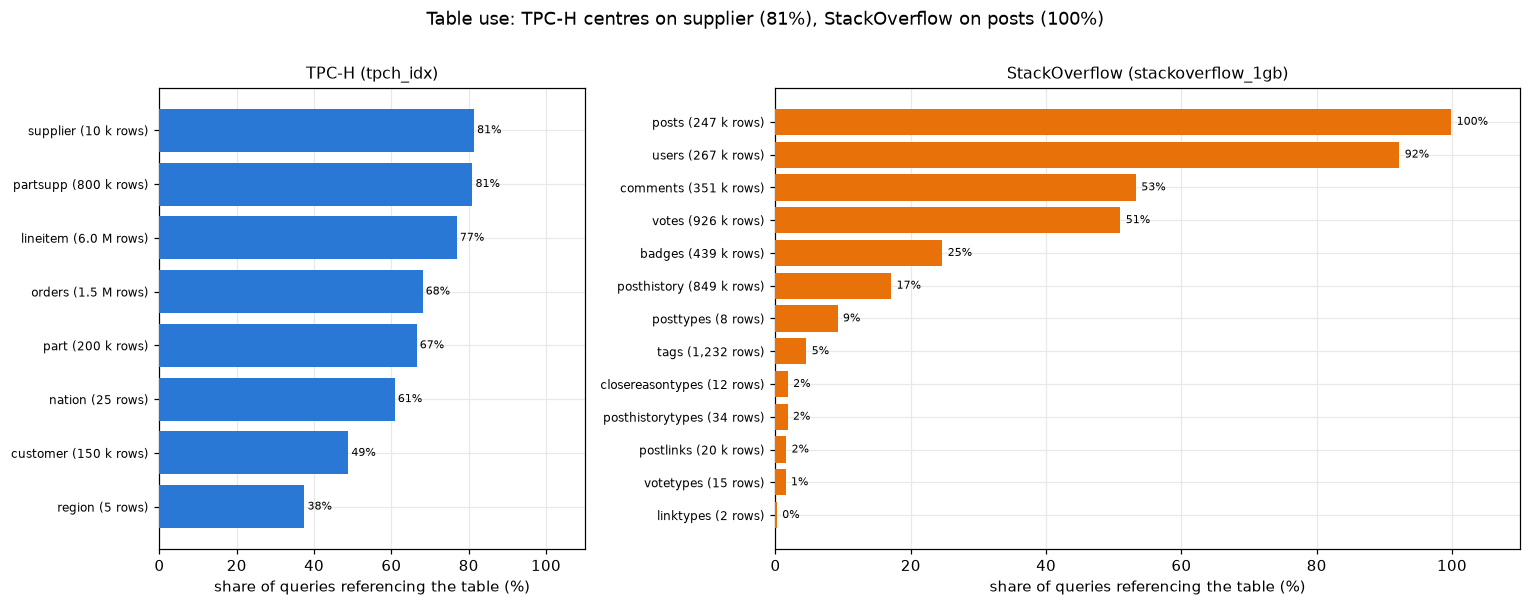

In [6]:
def rows_fmt(n):
    return f"{n:,.0f} rows" if n < 1e4 else f"{n / 1e3:,.0f} k rows" if n < 1e6 else f"{n / 1e6:.1f} M rows"


fig, axes = plt.subplots(1, 2, figsize=(14, 5.4), gridspec_kw={"width_ratios": [8, 14]})
TOPTAB = {}
for ax, k in zip(axes, KEYS):
    tv = pd.Series({tb: 100 * FEAT[k][f"tbl_{tb}"].mean() for tb in TABLES[k]}).sort_values()
    TOPTAB[k] = tv
    y = np.arange(len(tv))
    ax.barh(y, tv.values, color=DCOL[k], zorder=3)
    for i, (tb, v) in enumerate(tv.items()):
        ax.text(v + 0.8, i, f"{v:.0f}%", va="center", fontsize=7.5)
    ax.set_yticks(y)
    ax.set_yticklabels([f"{tb} ({rows_fmt(CAT[k].loc[tb, 'reltuples'])})" for tb in tv.index],
                       fontsize=8)
    ax.set_xlim(0, 110); ax.set_xlabel("share of queries referencing the table (%)")
    ax.set_title(f"{LBL[k]} ({DATASETS[k]['db']})", fontsize=10.5)
fig.suptitle(f"Table use: TPC-H centres on {TOPTAB['tpch'].idxmax()} "
             f"({TOPTAB['tpch'].max():.0f}%), StackOverflow on {TOPTAB['stackoverflow'].idxmax()} "
             f"({TOPTAB['stackoverflow'].max():.0f}%)", fontsize=12, y=1.01)
fig.tight_layout(); savefig(fig, "sqlstorm_table_freq"); plt.show()

## 5. SQL function usage

Share of each corpus calling each aggregate and scalar / string / date function.

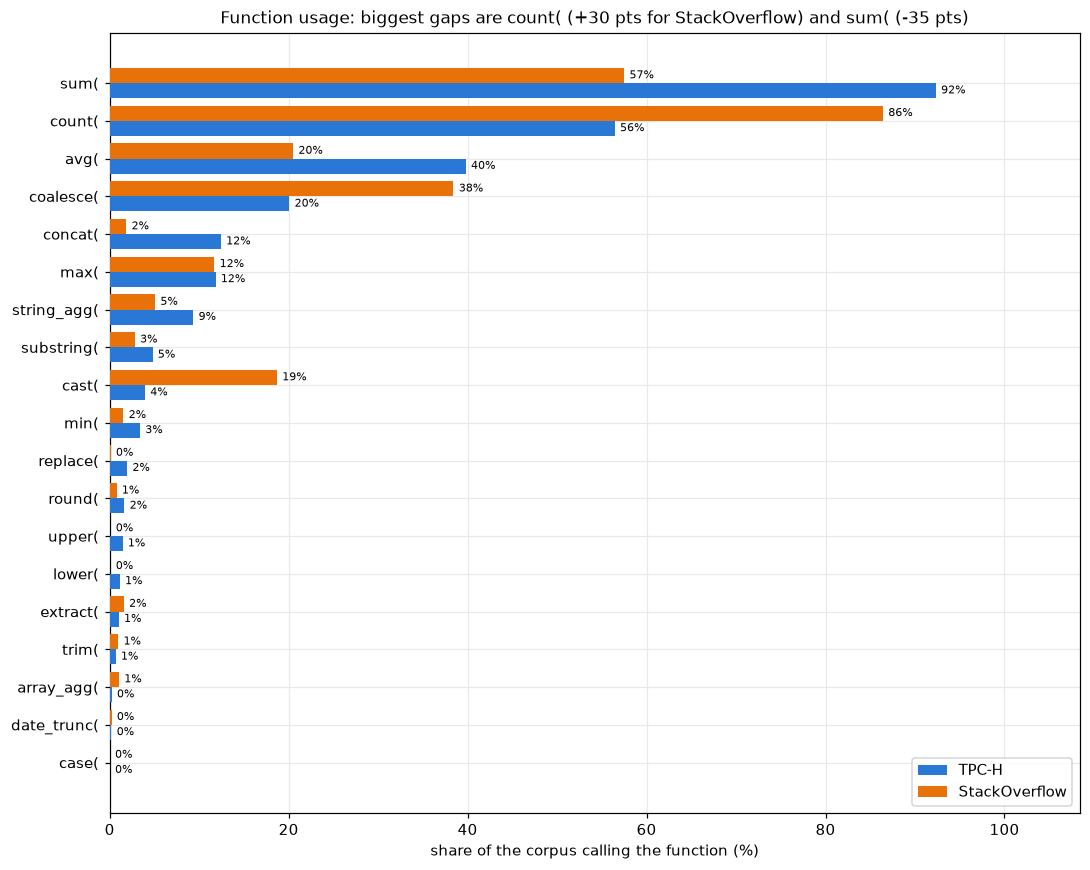

In [7]:
FF = pd.DataFrame({k: {fn + "(": 100 * FEAT[k][f"fn_{fn}"].mean() for fn in AGGS + STRFUN}
                   for k in KEYS}).sort_values("tpch")
fig, ax = plt.subplots(figsize=(10, 8))
grouped_barh(ax, FF)
ax.set_xlabel("share of the corpus calling the function (%)")
ax.set_xlim(0, FF.max().max() * 1.12 + 5); ax.legend(loc="lower right")
d = FF["stackoverflow"] - FF["tpch"]
ax.set_title(f"Function usage: biggest gaps are {d.idxmax()} ({d.max():+.0f} pts for StackOverflow) "
             f"and {d.idxmin()} ({d.min():+.0f} pts)", fontsize=11)
fig.tight_layout(); savefig(fig, "sqlstorm_function_freq"); plt.show()

## 6. Run outcomes — pass, timeout, error

A measured row is `failed=1` when the query errored **or** hit the 15 s statement timeout; a failure
at the ceiling (`elapsed ≥ 14.5 s`) is a **timeout**, anything shorter an **error**. If the
StackOverflow run is still in progress, its shares are over the queries measured so far (coverage
is printed). StackOverflow's error share is near zero by construction: upstream already removed the
queries PostgreSQL rejects (see §1a).

TPC-H          measured  17036 of 17036 (100%)  ok 14380 (84.4%)  timeout 2309 (13.6%)  error 347 (2.0%)
StackOverflow  measured  11794 of 11794 (100%)  ok 11474 (97.3%)  timeout 320 (2.7%)  error 0 (0.0%)


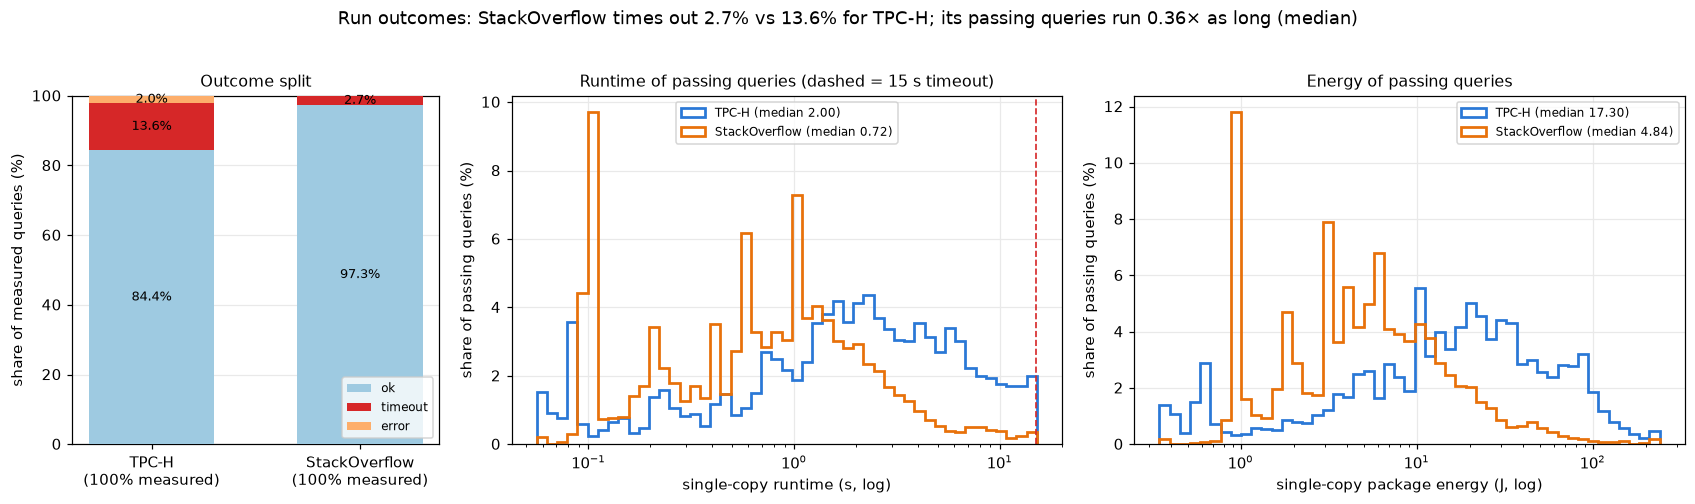

In [8]:
TIMEOUT_S = 14.5
TIM = {}
for k in KEYS:
    d = DATASETS[k]
    t = pd.read_csv(d["lcache"] / f"query_timing_{d['db']}.csv")
    for c in ["elapsed_sec", "rapl_pkg_j", "failed"]:
        t[c] = pd.to_numeric(t[c], errors="coerce")
    t = t[t["phase"] == "measured"].copy()
    t["qid"] = t["query"].astype(str).str.replace(r"^.*/", "", regex=True).str.replace(r"\.sql$", "", regex=True)
    t["failed"] = t["failed"].fillna(0).astype(int)
    t["category"] = np.where(t["failed"] == 0, "ok",
                             np.where(t["elapsed_sec"] >= TIMEOUT_S, "timeout", "error"))
    t["P"] = t["rapl_pkg_j"] / t["elapsed_sec"]
    TIM[k] = t.drop_duplicates("qid", keep="last")
COVER = {k: len(TIM[k]) / DATASETS[k]["expect"] for k in KEYS}
OUT = pd.DataFrame({LBL[k]: TIM[k]["category"].value_counts(normalize=True).reindex(
    ["ok", "timeout", "error"]).fillna(0) * 100 for k in KEYS}).T
for k in KEYS:
    print(f"{LBL[k]:14} measured {len(TIM[k]):6} of {DATASETS[k]['expect']} ({100 * COVER[k]:.0f}%)  " +
          "  ".join(f"{c} {int((TIM[k]['category'] == c).sum())} ({OUT.loc[LBL[k], c]:.1f}%)"
                    for c in ["ok", "timeout", "error"]))

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.4), gridspec_kw={"width_ratios": [0.8, 1.2, 1.2]})
ocol = {"ok": "#9ecae1", "timeout": "#d62728", "error": "#fdae6b"}
left = np.zeros(len(OUT))
for c in ["ok", "timeout", "error"]:
    axes[0].bar(range(len(OUT)), OUT[c], bottom=left, color=ocol[c], label=c, zorder=3, width=0.6)
    for i, (v, b0) in enumerate(zip(OUT[c], left)):
        if v >= 2:
            axes[0].text(i, b0 + v / 2, f"{v:.1f}%", ha="center", va="center", fontsize=8.5)
    left += OUT[c].to_numpy()
axes[0].set_xticks(range(len(OUT)))
axes[0].set_xticklabels([f"{LBL[k]}\n({100 * COVER[k]:.0f}% measured)" for k in KEYS])
axes[0].set_ylabel("share of measured queries (%)"); axes[0].set_ylim(0, 100)
axes[0].legend(fontsize=8, loc="lower right"); axes[0].set_title("Outcome split", fontsize=10.5)
for ax, col, xl, lo in [(axes[1], "elapsed_sec", "single-copy runtime (s, log)", 1e-3),
                        (axes[2], "rapl_pkg_j", "single-copy package energy (J, log)", 1e-2)]:
    allv = pd.concat([TIM[k][TIM[k]["category"] == "ok"][col] for k in KEYS])
    allv = allv[allv > lo]
    bins = np.logspace(np.log10(allv.min()), np.log10(allv.max()), 50)
    for k in KEYS:
        v = TIM[k][(TIM[k]["category"] == "ok") & (TIM[k][col] > lo)][col]
        ax.hist(v, bins=bins, weights=np.full(len(v), 100 / len(v)), histtype="step", lw=1.8,
                color=DCOL[k], label=f"{LBL[k]} (median {v.median():.2f})")
    ax.set_xscale("log"); ax.set_xlabel(xl); ax.set_ylabel("share of passing queries (%)")
    ax.legend(fontsize=8)
axes[1].axvline(15, color="#d62728", ls="--", lw=1.1)
axes[1].set_title("Runtime of passing queries (dashed = 15 s timeout)", fontsize=10.5)
axes[2].set_title("Energy of passing queries", fontsize=10.5)
okm = {k: TIM[k][TIM[k]["category"] == "ok"] for k in KEYS}
ratio_t = okm["stackoverflow"]["elapsed_sec"].median() / okm["tpch"]["elapsed_sec"].median()
fig.suptitle(f"Run outcomes: StackOverflow times out {OUT.loc['StackOverflow', 'timeout']:.1f}% vs "
             f"{OUT.loc['TPC-H', 'timeout']:.1f}% for TPC-H; its passing queries run "
             f"{ratio_t:.2f}× as long (median)", fontsize=12, y=1.03)
fig.tight_layout(); savefig(fig, "sqlstorm_runtime_energy"); plt.show()

## 7. Energy bands, power and parallelism

The slope-sample tiers (`slope_sample.ipynb`) are chosen per single-copy energy band, so the band
mix decides how expensive a full measurement of each corpus is. Power `P = E/t` and the share of
plans that launch 4 parallel workers (from the samples file) explain part of the difference.

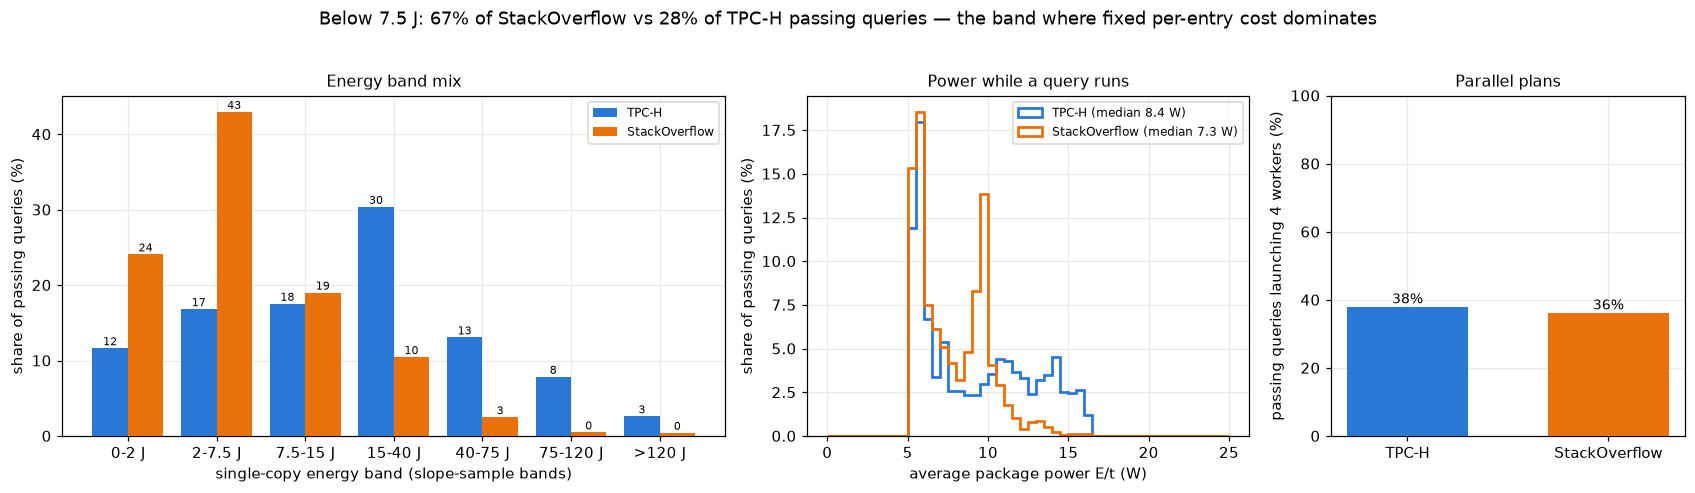

In [9]:
BAND_ORDER = ["0-2", "2-7.5", "7.5-15", "15-40", "40-75", "75-120", ">120"]
BAND_EDGES = [0, 2, 7.5, 15, 40, 75, 120, np.inf]
WK = {}
for k in KEYS:
    d = DATASETS[k]
    s = pd.read_csv(d["lcache"] / f"query_samples_{d['db']}.csv",
                    usecols=["query", "phase", "workers_launched"])
    s = s[s["phase"] == "measured"]
    s["qid"] = s["query"].astype(str).str.replace(r"^.*/", "", regex=True).str.replace(r"\.sql$", "", regex=True)
    WK[k] = pd.to_numeric(s["workers_launched"], errors="coerce").groupby(s["qid"]).max()

BANDS = pd.DataFrame({LBL[k]: pd.cut(okm[k]["rapl_pkg_j"], BAND_EDGES, labels=BAND_ORDER, right=False)
                      .value_counts(normalize=True).reindex(BAND_ORDER) * 100 for k in KEYS})
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.3), gridspec_kw={"width_ratios": [1.5, 1, 0.8]})
x = np.arange(len(BAND_ORDER)); w = 0.4
for i, k in enumerate(KEYS):
    axes[0].bar(x + (i - 0.5) * w, BANDS[LBL[k]], w, color=DCOL[k], label=LBL[k], zorder=3)
    for xx, v in zip(x + (i - 0.5) * w, BANDS[LBL[k]]):
        axes[0].text(xx, v + 0.4, f"{v:.0f}", ha="center", fontsize=7.5)
axes[0].set_xticks(x); axes[0].set_xticklabels([f"{b} J" for b in BAND_ORDER])
axes[0].set_xlabel("single-copy energy band (slope-sample bands)")
axes[0].set_ylabel("share of passing queries (%)"); axes[0].legend(fontsize=8)
axes[0].set_title("Energy band mix", fontsize=10.5)
pb = np.linspace(0, 25, 51)
for k in KEYS:
    p = okm[k]["P"].dropna()
    axes[1].hist(p.clip(upper=25), bins=pb, weights=np.full(len(p), 100 / len(p)), histtype="step",
                 lw=1.8, color=DCOL[k], label=f"{LBL[k]} (median {p.median():.1f} W)")
axes[1].set_xlabel("average package power E/t (W)"); axes[1].set_ylabel("share of passing queries (%)")
axes[1].legend(fontsize=8); axes[1].set_title("Power while a query runs", fontsize=10.5)
par = pd.Series({LBL[k]: 100 * (WK[k].reindex(okm[k]["qid"]) == 4).mean() for k in KEYS})
axes[2].bar(range(len(par)), par.values, color=[DCOL[k] for k in KEYS], width=0.6, zorder=3)
for i, v in enumerate(par.values):
    axes[2].text(i, v + 1, f"{v:.0f}%", ha="center", fontsize=9)
axes[2].set_xticks(range(len(par))); axes[2].set_xticklabels(par.index)
axes[2].set_ylabel("passing queries launching 4 workers (%)"); axes[2].set_ylim(0, 100)
axes[2].set_title("Parallel plans", fontsize=10.5)
light = {k: BANDS.loc[["0-2", "2-7.5"], LBL[k]].sum() for k in KEYS}
fig.suptitle(f"Below 7.5 J: {light['stackoverflow']:.0f}% of StackOverflow vs {light['tpch']:.0f}% of "
             f"TPC-H passing queries — the band where fixed per-entry cost dominates", fontsize=12, y=1.03)
fig.tight_layout(); savefig(fig, "sqlstorm_bands_power_parallel"); plt.show()

## 8. What times out, and the failed / timeout query lists

Timeout rate against the number of tables referenced, the outcome split for a few expensive
constructs, and the exported query lists per dataset.

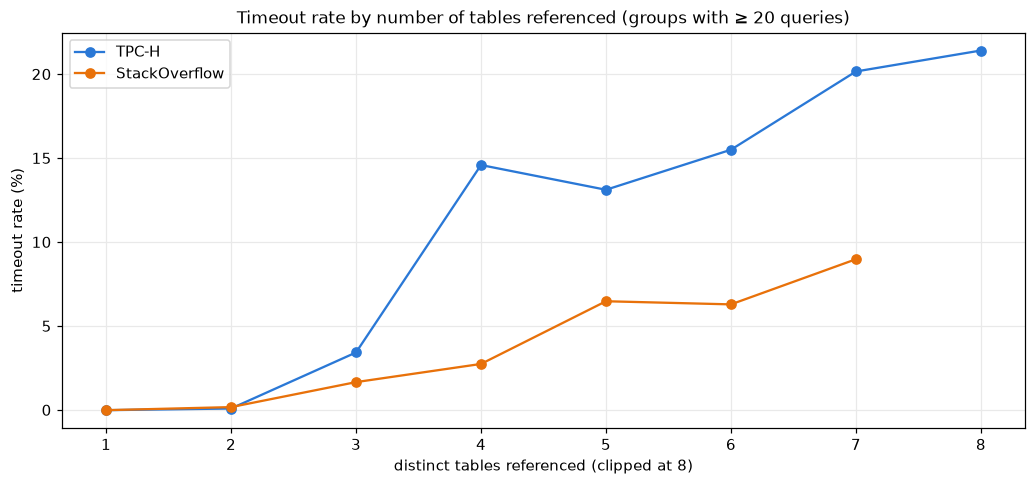

                          n              timeout %             error %      
dataset       StackOverflow    TPC-H StackOverflow TPC-H StackOverflow TPC-H
construct                                                                   
CTE (WITH)           7006.0   9293.0           4.2  17.9           0.0   3.5
all                 11794.0  17036.0           2.7  13.6           0.0   2.0
recursive CTE         221.0   1805.0           4.1  21.8           0.0  11.0
subquery             7246.0   9507.0           4.0  17.7           0.0   3.5
window (OVER)        5098.0   7273.0           3.8  17.4           0.0   3.8

TPC-H: wrote csv/sqlstorm_failed_queries.csv (2656 rows: 2309 timeout + 347 error) and csv/sqlstorm_timeout_queries.csv (2309 rows)

StackOverflow: wrote csv/sqlstorm_stackoverflow_failed_queries.csv (320 rows: 320 timeout + 0 error) and csv/sqlstorm_stackoverflow_timeout_queries.csv (320 rows)


In [10]:
FT = {k: TIM[k].merge(FEAT[k].reset_index()[["qid", "n_tables", "n_join", "is_cte", "has_window",
                                               "has_subquery", "has_recursive"]], on="qid", how="left")
      for k in KEYS}
fig, ax = plt.subplots(figsize=(9.5, 4.5))
for k in KEYS:
    g = FT[k].groupby(FT[k]["n_tables"].clip(upper=8))["category"]
    rate = g.apply(lambda s: 100 * (s == "timeout").mean())[g.size() >= 20]
    ax.plot(rate.index, rate.values, "-o", color=DCOL[k], label=LBL[k], zorder=3)
ax.set_xlabel("distinct tables referenced (clipped at 8)"); ax.set_ylabel("timeout rate (%)")
ax.legend(); ax.set_title("Timeout rate by number of tables referenced (groups with ≥ 20 queries)",
                          fontsize=11)
fig.tight_layout(); savefig(fig, "sqlstorm_timeout_by_tables"); plt.show()

rows = []
for k in KEYS:
    for lbl, col in [("all", None), ("CTE (WITH)", "is_cte"), ("recursive CTE", "has_recursive"),
                     ("window (OVER)", "has_window"), ("subquery", "has_subquery")]:
        sub = FT[k] if col is None else FT[k][FT[k][col] == True]
        if len(sub):
            rows.append({"dataset": LBL[k], "construct": lbl, "n": len(sub),
                         "timeout %": round(100 * (sub["category"] == "timeout").mean(), 1),
                         "error %": round(100 * (sub["category"] == "error").mean(), 1)})
print(pd.DataFrame(rows).pivot(index="construct", columns="dataset",
                               values=["n", "timeout %", "error %"]).to_string())

cols = ["qid", "query", "elapsed_sec", "rapl_pkg_j", "n_tables", "n_join"]
for k in KEYS:
    pre = DATASETS[k]["csv_prefix"]
    failed = FT[k][FT[k]["failed"] == 1][cols + ["category"]].sort_values("qid")
    timeout = FT[k][FT[k]["category"] == "timeout"][cols].sort_values("qid")
    failed.to_csv(f"{pre}failed_queries.csv", index=False)
    timeout.to_csv(f"{pre}timeout_queries.csv", index=False)
    print(f"\n{LBL[k]}: wrote {pre}failed_queries.csv ({len(failed)} rows: "
          f"{int((failed['category'] == 'timeout').sum())} timeout + "
          f"{int((failed['category'] == 'error').sum())} error) and {pre}timeout_queries.csv "
          f"({len(timeout)} rows)")

## 9. Complexity vs runtime (passing queries)

Median single-copy runtime and energy by number of tables referenced, per dataset.

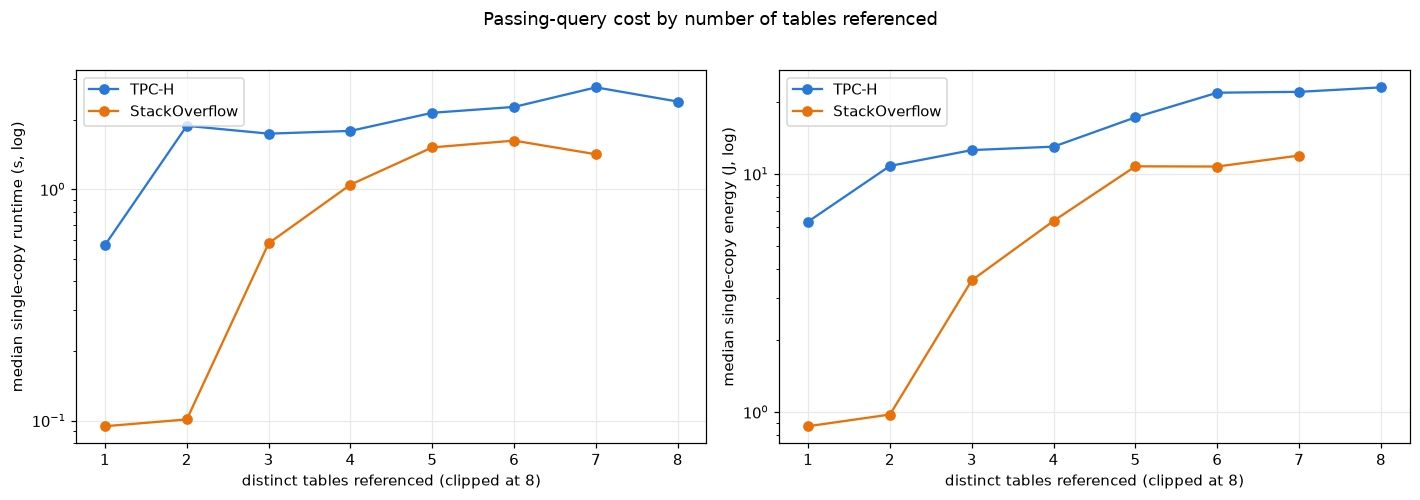

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
for ax, col, yl in [(axes[0], "elapsed_sec", "median single-copy runtime (s, log)"),
                    (axes[1], "rapl_pkg_j", "median single-copy energy (J, log)")]:
    for k in KEYS:
        okft = FT[k][(FT[k]["category"] == "ok") & (FT[k][col] > 0)]
        g = okft.groupby(okft["n_tables"].clip(upper=8))[col]
        med = g.median()[g.size() >= 20]
        ax.plot(med.index, med.values, "-o", color=DCOL[k], label=LBL[k], zorder=3)
    ax.set_yscale("log"); ax.set_xlabel("distinct tables referenced (clipped at 8)")
    ax.set_ylabel(yl); ax.legend()
fig.suptitle("Passing-query cost by number of tables referenced", fontsize=12, y=1.02)
fig.tight_layout(); savefig(fig, "sqlstorm_runtime_by_tables"); plt.show()